In [1]:
import pandas as pd
import os
dataset_path=r"C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA"
audio_files=[]
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            full_path=os.path.join(root, file)
            audio_files.append(full_path)

print("total files:",len(audio_files))
print("sample files:",audio_files[:5])



total files: 1440
sample files: ['C:\\Users\\aksha\\OneDrive\\Desktop\\Emotion Recognition\\datasets\\AUDIO DATA\\Actor_01\\03-01-01-01-01-01-01.wav', 'C:\\Users\\aksha\\OneDrive\\Desktop\\Emotion Recognition\\datasets\\AUDIO DATA\\Actor_01\\03-01-01-01-01-02-01.wav', 'C:\\Users\\aksha\\OneDrive\\Desktop\\Emotion Recognition\\datasets\\AUDIO DATA\\Actor_01\\03-01-01-01-02-01-01.wav', 'C:\\Users\\aksha\\OneDrive\\Desktop\\Emotion Recognition\\datasets\\AUDIO DATA\\Actor_01\\03-01-01-01-02-02-01.wav', 'C:\\Users\\aksha\\OneDrive\\Desktop\\Emotion Recognition\\datasets\\AUDIO DATA\\Actor_01\\03-01-02-01-01-01-01.wav']


In [2]:
print(os.listdir(dataset_path))

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


In [3]:
emotion_map={
    "01":"neutral",
    "02":"calm",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fear",
    "07":"disgust",
    "08":"surprise"
}
data=[]
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            file_path=os.path.join(root,file)
            emotion_code=file.split("-")[2]
            emotion=emotion_map[emotion_code]
            data.append([file_path,emotion])

df=pd.DataFrame(data,columns=["file_path","emotion"])
print(df.head())

                                           file_path  emotion
0  C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...  neutral
1  C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...  neutral
2  C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...  neutral
3  C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...  neutral
4  C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...     calm


In [4]:
for root,dirs,files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            print(file)
            print(root)
            print(dirs)
            print(os.path.join(root,file))

03-01-01-01-01-01-01.wav
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01
[]
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01\03-01-01-01-01-01-01.wav
03-01-01-01-01-02-01.wav
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01
[]
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01\03-01-01-01-01-02-01.wav
03-01-01-01-02-01-01.wav
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01
[]
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01\03-01-01-01-02-01-01.wav
03-01-01-01-02-02-01.wav
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01
[]
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01\03-01-01-01-02-02-01.wav
03-01-02-01-01-01-01.wav
C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01
[]
C:\Users\aksha\OneDrive\Desktop

In [5]:
import librosa
import numpy as np
def extract_features(file):
    audio, sr = librosa.load(file, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_scaled = np.mean(mfcc.T,axis=0)
    return mfcc_scaled

In [6]:
features=[]
audio_files=df["file_path"].values
labels=df["emotion"].values
for file in audio_files:
    data = extract_features(file)
    features.append(data)

x=np.array(features)

C:\Users\aksha\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\aksha\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\aksha\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [7]:
print(x.shape)

(1440, 40)


In [8]:
y=np.array(labels)

In [9]:
print(x[0])

[-6.7019543e+02  6.5063850e+01  8.8895434e-01  1.4715979e+01
  9.1821651e+00  6.6057479e-01 -3.8468361e+00 -3.5839460e+00
 -1.2959006e+01 -3.3001330e+00  9.1077960e-01 -3.5970359e+00
  2.3762743e+00 -4.3889413e+00  5.4508036e-01  8.9185166e-01
 -4.8025908e+00 -2.1054139e+00 -1.6059692e+00 -1.0523903e+00
 -7.0672808e+00 -6.2306100e-01 -2.7280300e+00 -5.3073611e+00
 -1.9691168e+00 -9.4615275e-01 -5.7211108e+00  3.3299115e-01
 -2.5438452e+00  1.8220828e-01 -2.3510973e+00 -2.5047269e+00
 -3.1515074e+00 -2.1908991e+00 -3.8017602e+00 -1.8130876e+00
 -1.2612222e+00 -2.1449544e+00 -4.1521730e+00 -1.7796155e+00]


In [10]:
print(y[0])

neutral


In [15]:
file=r"C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\AUDIO DATA\Actor_01\03-01-03-02-01-02-01.wav"
audio, sr = librosa.load(file, duration=3, offset=0.5)
print(sr)
print(audio.shape)

mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
print(mfcc)
print(mfcc.shape)
print(mfcc.T.shape)
mfcc_scaled = np.mean(mfcc.T,axis=0)
print(mfcc_scaled)
print(mfcc_scaled.shape)

22050
(66150,)
[[-7.2669629e+02 -7.2326550e+02 -7.1273169e+02 ... -7.2669629e+02
  -7.2669629e+02 -7.2669629e+02]
 [ 0.0000000e+00  2.6805296e+00  1.2554233e+01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00 -1.0738319e+00 -7.4637532e-01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 ...
 [ 0.0000000e+00  7.9579338e-02 -3.4634572e-01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00 -2.1311475e-01 -1.8481417e+00 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  7.2251707e-01 -3.3897316e-01 ...  0.0000000e+00
   0.0000000e+00  0.0000000e+00]]
(40, 130)
(130, 40)
[-5.2563245e+02  6.5396561e+01 -1.3422568e+01  7.1148386e+00
  2.4793038e+00 -2.8943148e+00 -1.3134979e+01 -8.3123493e+00
 -1.7194006e+01 -9.4874220e+00  3.2600136e+00 -9.4451666e+00
 -1.7099079e+00 -2.5320830e+00 -7.8684645e+00  4.5009577e-01
 -8.7105684e+00 -6.7232742e+00 -2.7868094e+00 -5.5558443e+00
 -7.4254189e+00 -4.9995346e+00 -4.1822939e+00 -5.4609871e+00

In [16]:
df=pd.DataFrame(x)
df.columns=[f"mfcc_{i+1}" for i in range(40)]
df["emotion"]=y
df.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39,mfcc_40,emotion
0,-670.195435,65.063850,0.888954,14.715979,9.182165,0.660575,-3.846836,-3.583946,-12.959006,-3.300133,...,-2.504727,-3.151507,-2.190899,-3.801760,-1.813088,-1.261222,-2.144954,-4.152173,-1.779616,neutral
1,-660.230347,63.325817,-2.630457,17.983355,9.407703,-0.981498,-2.324697,-6.848032,-14.133670,-2.200332,...,-3.113372,-2.556752,-2.935112,-3.654962,-0.988048,-1.499825,-3.617125,-3.751694,-2.730914,neutral
2,-661.964478,66.655869,-0.932158,14.899042,5.324703,0.474343,-3.346651,-7.102525,-12.873403,-5.088379,...,-2.643650,-2.937167,-2.361648,-3.345104,-2.426059,-1.460013,-3.281310,-4.208614,-2.726205,neutral
3,-657.722351,65.035187,3.148672,15.666511,7.582657,2.628087,-1.850069,-7.477578,-11.976265,-4.458463,...,-2.849611,-3.591487,-3.104016,-3.495707,-1.628411,-1.304878,-3.032794,-3.973964,-3.861779,neutral
4,-694.579590,72.531715,3.104562,17.112118,9.077339,1.836256,-4.146086,-4.797152,-11.764125,-5.925480,...,-1.405873,-2.290345,-2.879143,-2.069092,-0.544464,-2.073817,-2.080611,-4.573941,-3.246941,calm


In [17]:
df.shape

(1440, 41)

In [18]:
df.to_csv(r"C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\mfcc_emotion.csv",index=False)

In [21]:
df_full=pd.DataFrame(x)
df_full.columns=[f"mfcc_{i+1}"for i in range(40)]
df_full["emotion"]=y
df_full["file_path"]=audio_files
df_full.head()

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,...,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39,mfcc_40,emotion,file_path
0,-670.195435,65.063850,0.888954,14.715979,9.182165,0.660575,-3.846836,-3.583946,-12.959006,-3.300133,...,-3.151507,-2.190899,-3.801760,-1.813088,-1.261222,-2.144954,-4.152173,-1.779616,neutral,C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...
1,-660.230347,63.325817,-2.630457,17.983355,9.407703,-0.981498,-2.324697,-6.848032,-14.133670,-2.200332,...,-2.556752,-2.935112,-3.654962,-0.988048,-1.499825,-3.617125,-3.751694,-2.730914,neutral,C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...
2,-661.964478,66.655869,-0.932158,14.899042,5.324703,0.474343,-3.346651,-7.102525,-12.873403,-5.088379,...,-2.937167,-2.361648,-3.345104,-2.426059,-1.460013,-3.281310,-4.208614,-2.726205,neutral,C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...
3,-657.722351,65.035187,3.148672,15.666511,7.582657,2.628087,-1.850069,-7.477578,-11.976265,-4.458463,...,-3.591487,-3.104016,-3.495707,-1.628411,-1.304878,-3.032794,-3.973964,-3.861779,neutral,C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...
4,-694.579590,72.531715,3.104562,17.112118,9.077339,1.836256,-4.146086,-4.797152,-11.764125,-5.925480,...,-2.290345,-2.879143,-2.069092,-0.544464,-2.073817,-2.080611,-4.573941,-3.246941,calm,C:\Users\aksha\OneDrive\Desktop\Emotion Recogn...


In [22]:
df_full["file_path"][0]

'C:\\Users\\aksha\\OneDrive\\Desktop\\Emotion Recognition\\datasets\\AUDIO DATA\\Actor_01\\03-01-01-01-01-01-01.wav'

In [23]:
df_full.shape

(1440, 42)

In [24]:
df.shape

(1440, 42)

In [25]:
df1=pd.read_csv(r"C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\mfcc_emotion.csv")

In [26]:
df1.shape

(1440, 41)

In [27]:
df_full.to_csv(r"C:\Users\aksha\OneDrive\Desktop\Emotion Recognition\datasets\mfcc_filepath_emotion.csv")

In [29]:
df1["emotion"].value_counts()

emotion
calm        192
happy       192
sad         192
angry       192
fear        192
disgust     192
surprise    192
neutral      96
Name: count, dtype: int64

In [30]:
df["emotion"].nunique()

8

In [31]:
df["emotion"].unique()

array(['neutral', 'calm', 'happy', 'sad', 'angry', 'fear', 'disgust',
       'surprise'], dtype=object)

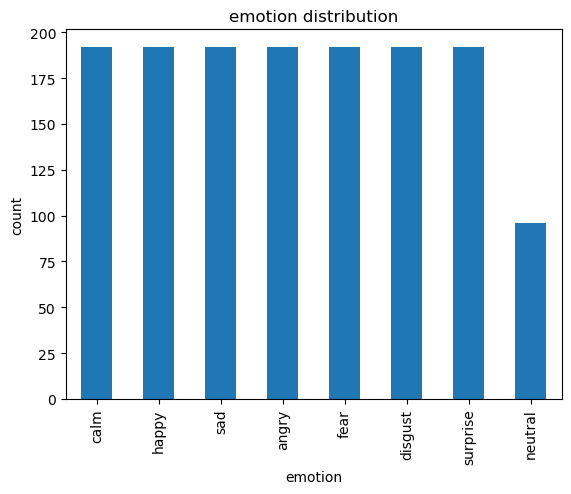

In [33]:
import matplotlib.pyplot as plt
df1["emotion"].value_counts().plot(kind="bar")
plt.title("emotion distribution")
plt.ylabel("count")
plt.show()

In [34]:
print(np.isnan(x).sum())

0


In [35]:
print(np.isna(y).sum())

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''